# Desafio 06 - Previsão de Consumo de Energia

**Disciplina:** Machine Learning - Teoria e Aplicado  
**Grupo:** 6  
**Dataset:** UCI - Electric Power Consumption  
**Tipo:** Regressão (Série Temporal)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
df = pd.read_csv('household_power_consumption.txt', sep=';',
                  low_memory=False, na_values='?')
print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [7]:
print('Valores faltantes por coluna:')
print(df.isnull().sum())
print(f'Total de linhas: {len(df)}')
print(f'Linhas com pelo menos 1 NaN: {df.isnull().any(axis=1).sum()}')

Valores faltantes por coluna:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Total de linhas: 2075259
Linhas com pelo menos 1 NaN: 25979


## Etapa 1 - Análise Exploratória (EDA)

In [8]:
if 'Date' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                     format='%d/%m/%Y %H:%M:%S')
    df.set_index('datetime', inplace=True)
    df.drop(columns=['Date', 'Time'], inplace=True)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Período: {df.index.min()} até {df.index.max()}')

Período: 2006-12-16 17:24:00 até 2010-11-26 21:02:00


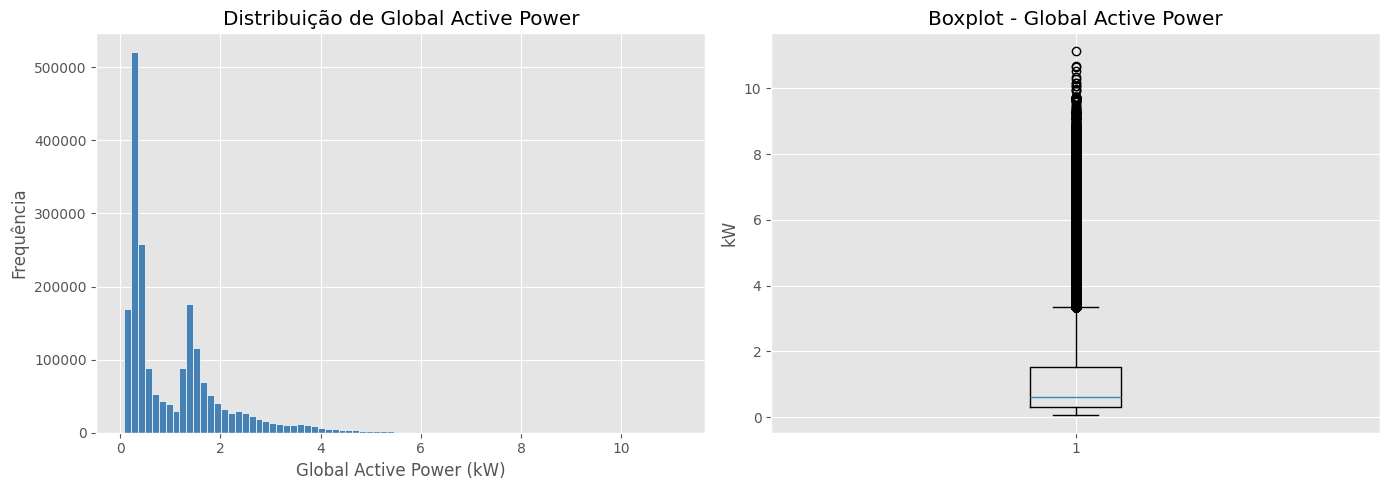

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Global_active_power'].dropna(), bins=80,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Global Active Power')
axes[0].set_xlabel('Global Active Power (kW)')
axes[0].set_ylabel('Frequência')

axes[1].boxplot(df['Global_active_power'].dropna(), vert=True)
axes[1].set_title('Boxplot - Global Active Power')
axes[1].set_ylabel('kW')

plt.tight_layout()
plt.show()

In [10]:
# reamostrando por hora pra facilitar visualização e modelagem
df_h = df.resample('h').mean()
df_h.dropna(inplace=True)

print(f'Shape depois do resample horário: {df_h.shape}')

Shape depois do resample horário: (34168, 7)


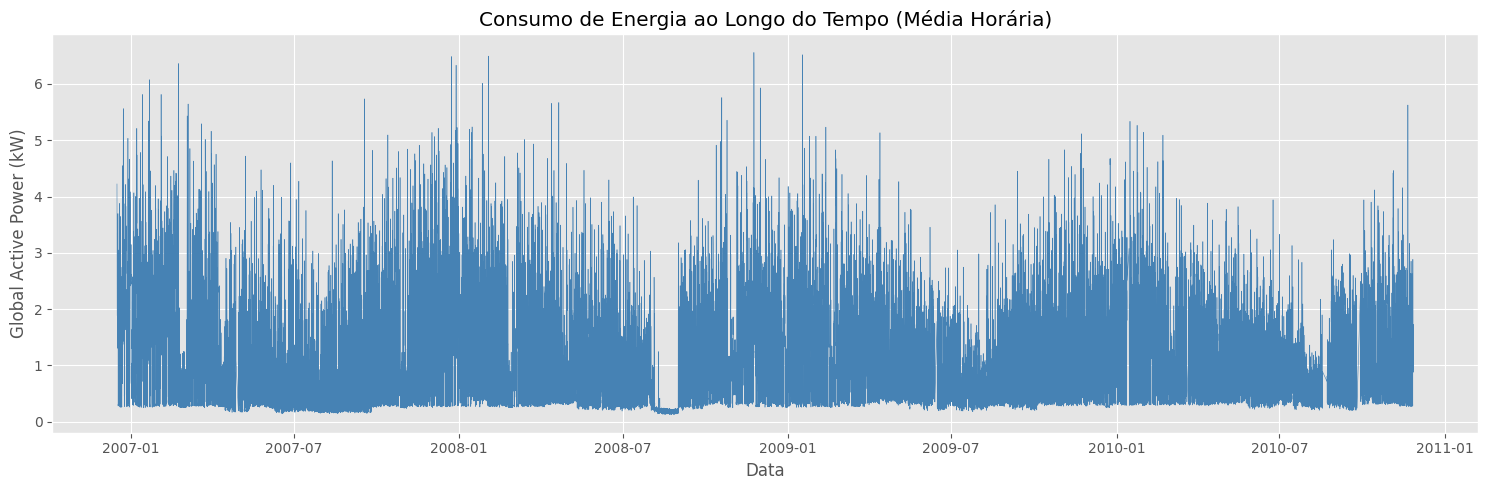

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_h.index, df_h['Global_active_power'], linewidth=0.4, color='steelblue')
ax.set_title('Consumo de Energia ao Longo do Tempo (Média Horária)')
ax.set_xlabel('Data')
ax.set_ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

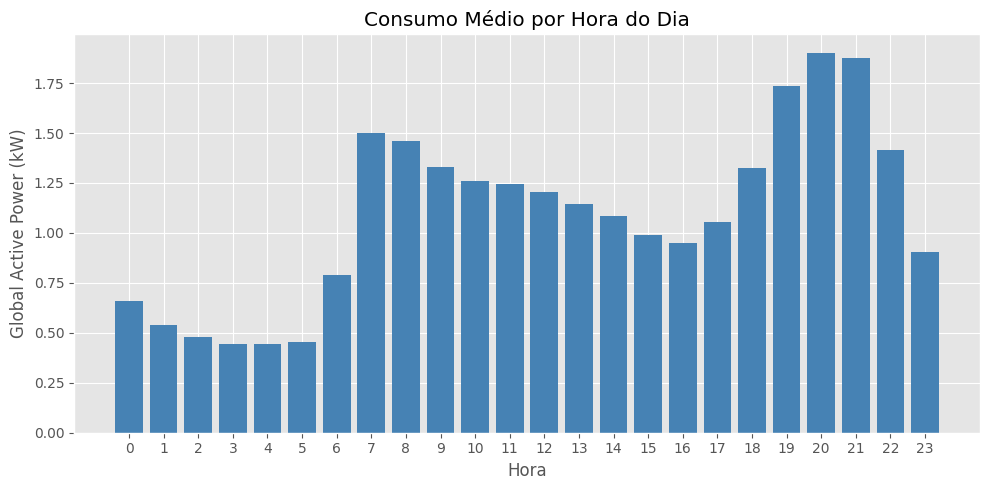

In [12]:
df_h['hour'] = df_h.index.hour

consumo_hora = df_h.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(10, 5))
plt.bar(consumo_hora.index, consumo_hora.values, color='steelblue')
plt.title('Consumo Médio por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Global Active Power (kW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

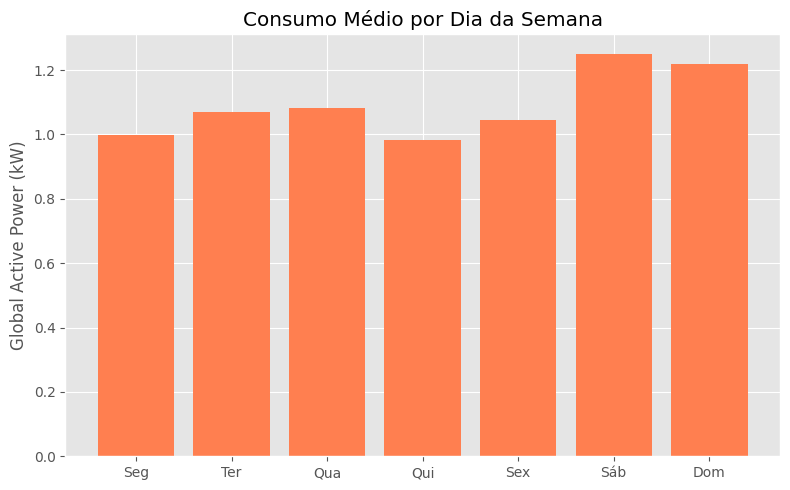

In [13]:
df_h['day_of_week'] = df_h.index.dayofweek

dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
consumo_dia = df_h.groupby('day_of_week')['Global_active_power'].mean()

plt.figure(figsize=(8, 5))
plt.bar(range(7), consumo_dia.values, color='coral', tick_label=dias)
plt.title('Consumo Médio por Dia da Semana')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

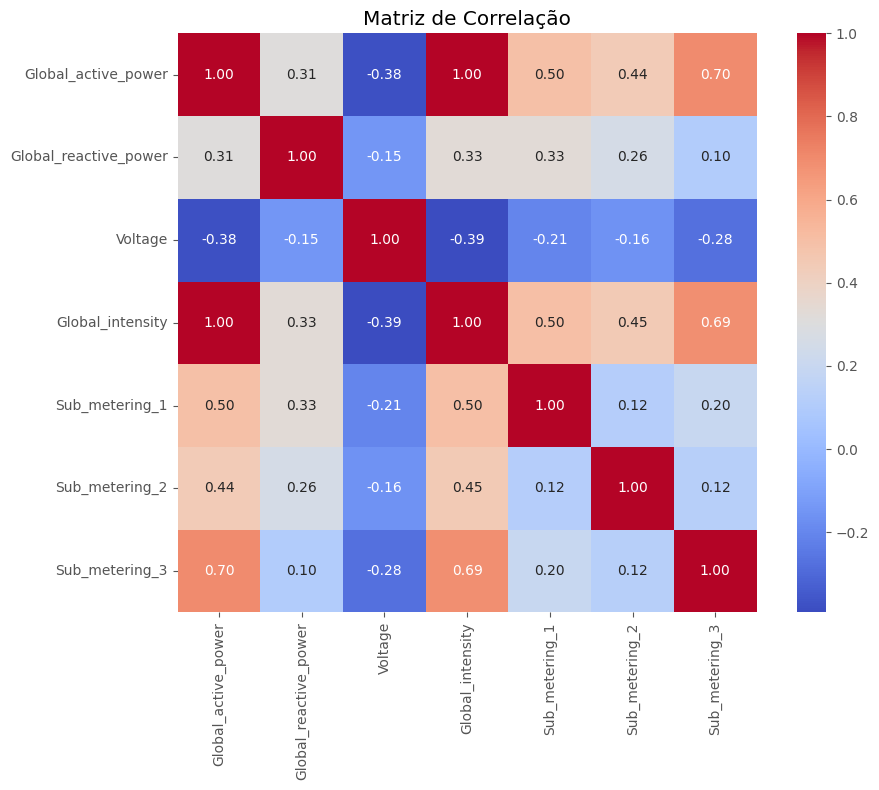

In [14]:
plt.figure(figsize=(10, 8))
corr = df_h[['Global_active_power', 'Global_reactive_power', 'Voltage',
              'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
              'Sub_metering_3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

## Etapa 2 - Pré-processamento

In [15]:
df_h['month'] = df_h.index.month
df_h['is_weekend'] = (df_h['day_of_week'] >= 5).astype(int)

# lag features - consumo da hora anterior e de 24h atras
df_h['lag_1h'] = df_h['Global_active_power'].shift(1)
df_h['lag_24h'] = df_h['Global_active_power'].shift(24)

df_h.dropna(inplace=True)

print(f'Shape após criar features: {df_h.shape}')
df_h.head()

Shape após criar features: (34144, 13)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,is_weekend,lag_1h,lag_24h
datetime,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,1,3.326033,4.222889
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,1,3.406767,3.632200
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,1,3.697100,3.400233
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,1,2.908400,3.268567
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,1,3.361500,3.056467


In [16]:
# removendo outliers com IQR
Q1 = df_h['Global_active_power'].quantile(0.25)
Q3 = df_h['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

antes = len(df_h)
df_h = df_h[(df_h['Global_active_power'] >= lim_inf) &
            (df_h['Global_active_power'] <= lim_sup)]

print(f'Removidos {antes - len(df_h)} outliers ({(antes - len(df_h))/antes*100:.1f}%)')
print(f'Shape: {df_h.shape}')

Removidos 732 outliers (2.1%)
Shape: (33412, 13)


In [17]:
features = ['hour', 'day_of_week', 'month', 'is_weekend',
            'Global_reactive_power', 'Voltage', 'Global_intensity',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
            'lag_1h', 'lag_24h']

X = df_h[features]
y = df_h['Global_active_power']

# divisão cronológica 70/15/15 (sem shuffle!)
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f'Treino:    {X_train.shape[0]} amostras ({X_train.index.min().date()} a {X_train.index.max().date()})')
print(f'Validação: {X_val.shape[0]} amostras ({X_val.index.min().date()} a {X_val.index.max().date()})')
print(f'Teste:     {X_test.shape[0]} amostras ({X_test.index.min().date()} a {X_test.index.max().date()})')

Treino:    23388 amostras (2006-12-17 a 2009-09-17)
Validação: 5012 amostras (2009-09-17 a 2010-04-22)
Teste:     5012 amostras (2010-04-22 a 2010-11-26)


In [18]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## Etapa 3 - Comparação de Modelos

In [19]:
def avaliar(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    print(f'--- {nome} ---')
    print(f'MAE:  {mae:.4f}')
    print(f'MSE:  {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')
    print(f'MAPE: {mape:.2f}%\n')

    return {'Modelo': nome, 'MAE': mae, 'MSE': mse,
            'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}

In [20]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)

pred_lr_val = lr.predict(X_val_s)
pred_lr_test = lr.predict(X_test_s)

res_lr = avaliar('Regressão Linear', y_test, pred_lr_test)

--- Regressão Linear ---
MAE:  0.0131
MSE:  0.0004
RMSE: 0.0209
R²:   0.9991
MAPE: 1.83%



In [21]:
# pra polinomial, usando um subconjunto de features pra não explodir a memória
feat_poly = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h']
idx_poly = [features.index(f) for f in feat_poly]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s[:, idx_poly])
X_val_poly = poly.transform(X_val_s[:, idx_poly])
X_test_poly = poly.transform(X_test_s[:, idx_poly])

print(f'Features polinomiais geradas: {X_train_poly.shape[1]}')

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

pred_poly_val = lr_poly.predict(X_val_poly)
pred_poly_test = lr_poly.predict(X_test_poly)

res_poly = avaliar('Regressão Polinomial (grau 2)', y_test, pred_poly_test)

Features polinomiais geradas: 27
--- Regressão Polinomial (grau 2) ---
MAE:  0.3491
MSE:  0.2368
RMSE: 0.4866
R²:   0.4901
MAPE: 48.35%



In [22]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=5, random_state=42,
                           n_jobs=-1)
rf.fit(X_train_s, y_train)

pred_rf_val = rf.predict(X_val_s)
pred_rf_test = rf.predict(X_test_s)

res_rf = avaliar('Random Forest', y_test, pred_rf_test)

--- Random Forest ---
MAE:  0.0133
MSE:  0.0005
RMSE: 0.0221
R²:   0.9989
MAPE: 1.86%



In [23]:
resultados = pd.DataFrame([res_lr, res_poly, res_rf])
resultados = resultados.set_index('Modelo')

resultados.style.highlight_min(axis=0, subset=['MAE', 'MSE', 'RMSE', 'MAPE (%)'], color='lightgreen')\
                .highlight_max(axis=0, subset=['R²'], color='lightgreen')\
                .format(precision=4)

,MAE,MSE,RMSE,R²,MAPE (%)
Modelo,,,,,
Regressão Linear,0.0131,0.0004,0.0209,0.9991,1.8274
Regressão Polinomial (grau 2),0.3491,0.2368,0.4866,0.4901,48.3504
Random Forest,0.0133,0.0005,0.0221,0.9989,1.8570


In [24]:
# validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for nome, modelo in [('Linear', LinearRegression()),
                      ('Random Forest', RandomForestRegressor(
                          n_estimators=100, max_depth=15,
                          random_state=42, n_jobs=-1))]:
    scores = []
    for train_idx, val_idx in tscv.split(X_train_s):
        modelo.fit(X_train_s[train_idx], y_train.iloc[train_idx])
        pred = modelo.predict(X_train_s[val_idx])
        scores.append(r2_score(y_train.iloc[val_idx], pred))

    cv_results[nome] = scores
    print(f'{nome} - R² médio CV: {np.mean(scores):.4f} (±{np.std(scores):.4f})')

Linear - R² médio CV: 0.9994 (±0.0001)
Random Forest - R² médio CV: 0.9993 (±0.0001)


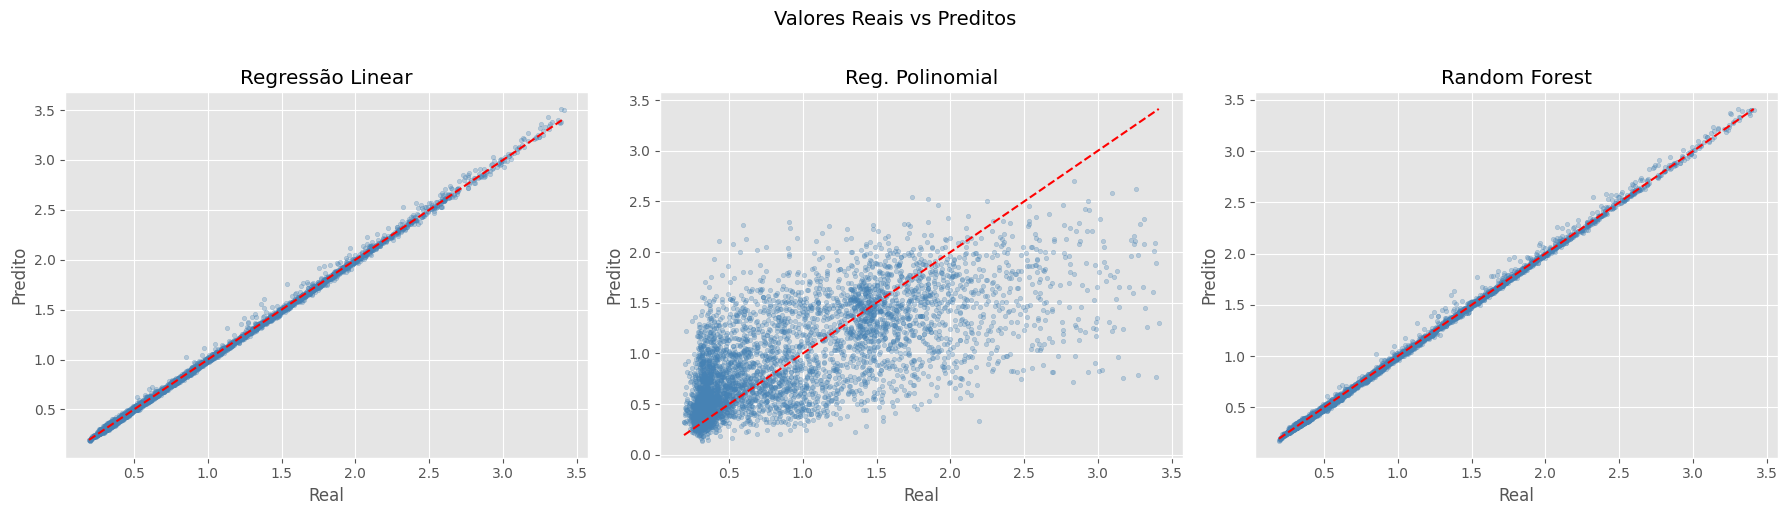

In [25]:
modelos_pred = [('Regressão Linear', pred_lr_test),
                ('Reg. Polinomial', pred_poly_test),
                ('Random Forest', pred_rf_test)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, pred) in zip(axes, modelos_pred):
    ax.scatter(y_test, pred, alpha=0.3, s=10, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    ax.set_title(nome)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predito')

plt.suptitle('Valores Reais vs Preditos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

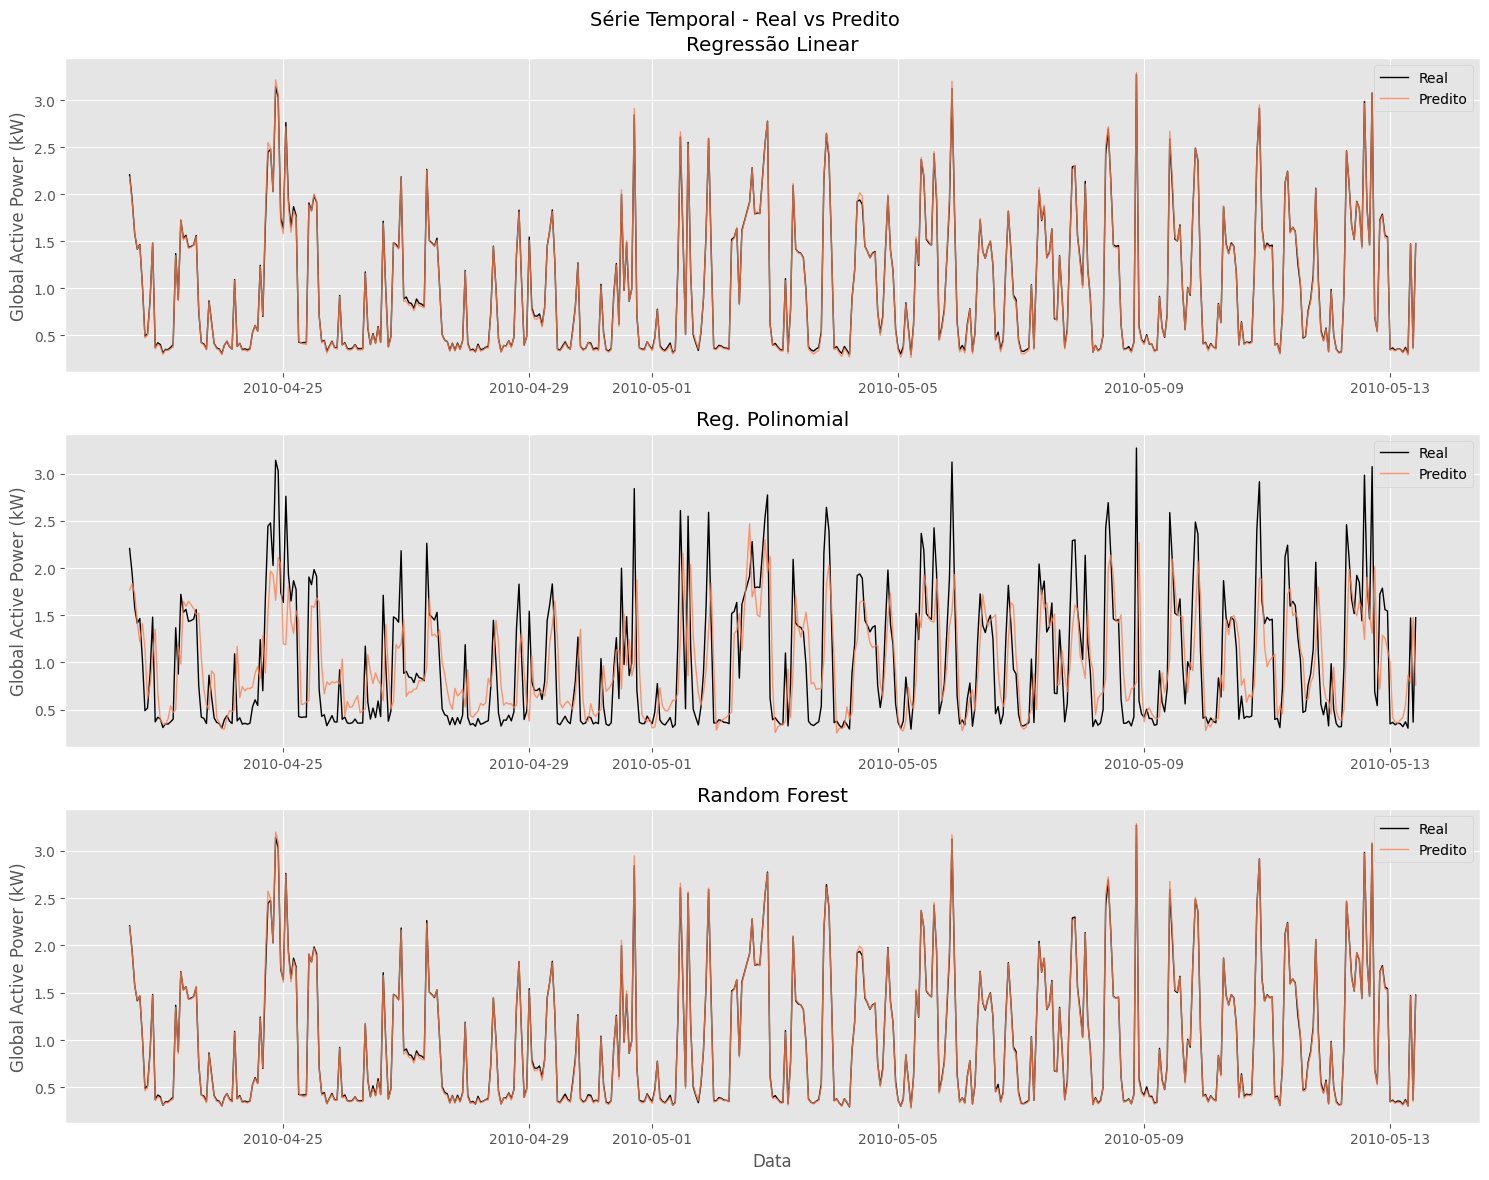

In [26]:
# série temporal real vs predito (janela menor pra ver melhor)
janela = 500

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for ax, (nome, pred) in zip(axes, modelos_pred):
    ax.plot(y_test.index[:janela], y_test.values[:janela],
            label='Real', linewidth=1, color='black')
    ax.plot(y_test.index[:janela], pred[:janela],
            label='Predito', linewidth=1, alpha=0.8, color='coral')
    ax.set_title(nome)
    ax.legend()
    ax.set_ylabel('Global Active Power (kW)')

axes[-1].set_xlabel('Data')
plt.suptitle('Série Temporal - Real vs Predito', fontsize=14)
plt.tight_layout()
plt.show()

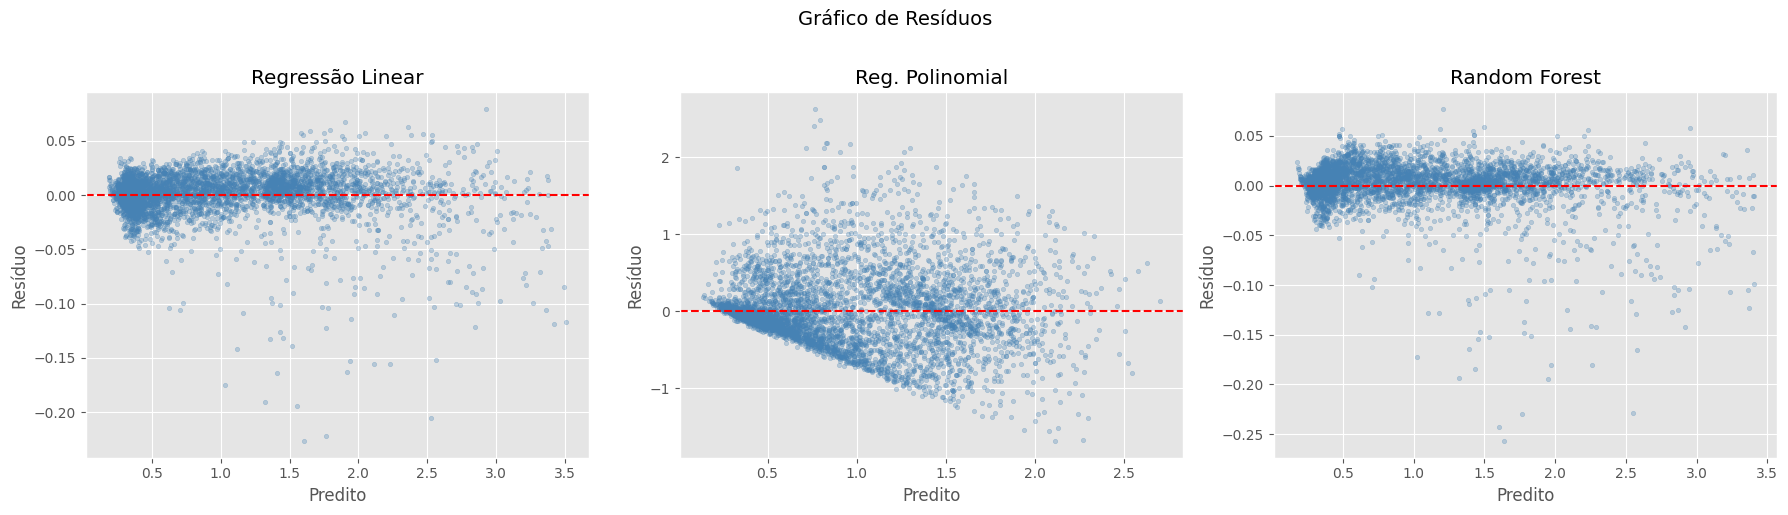

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, pred) in zip(axes, modelos_pred):
    residuos = y_test.values - pred
    ax.scatter(pred, residuos, alpha=0.3, s=10, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(nome)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Resíduo')

plt.suptitle('Gráfico de Resíduos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

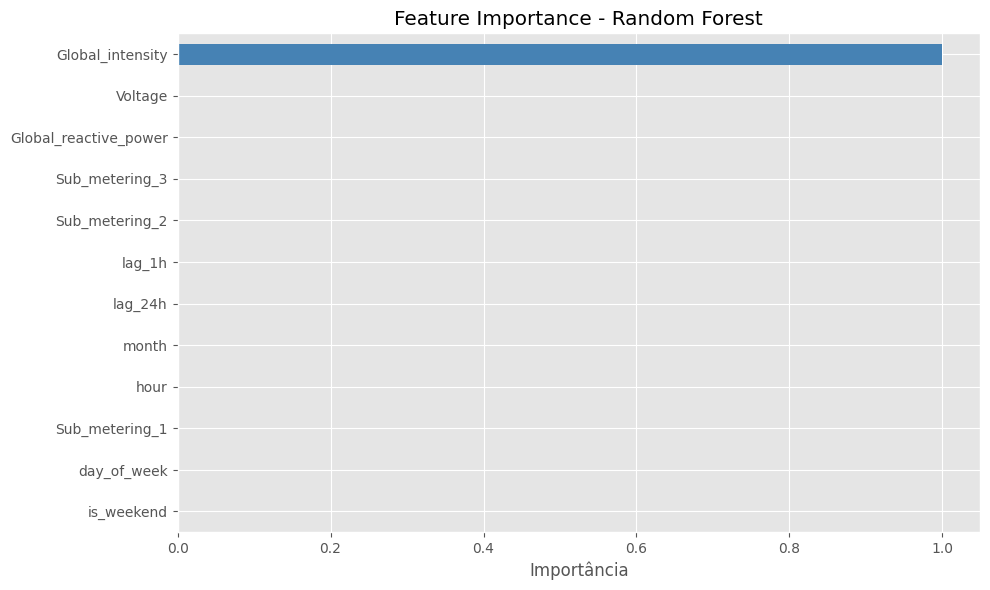

In [28]:
importancias = pd.Series(rf.feature_importances_,
                          index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## Etapa 4 - Análise Comparativa

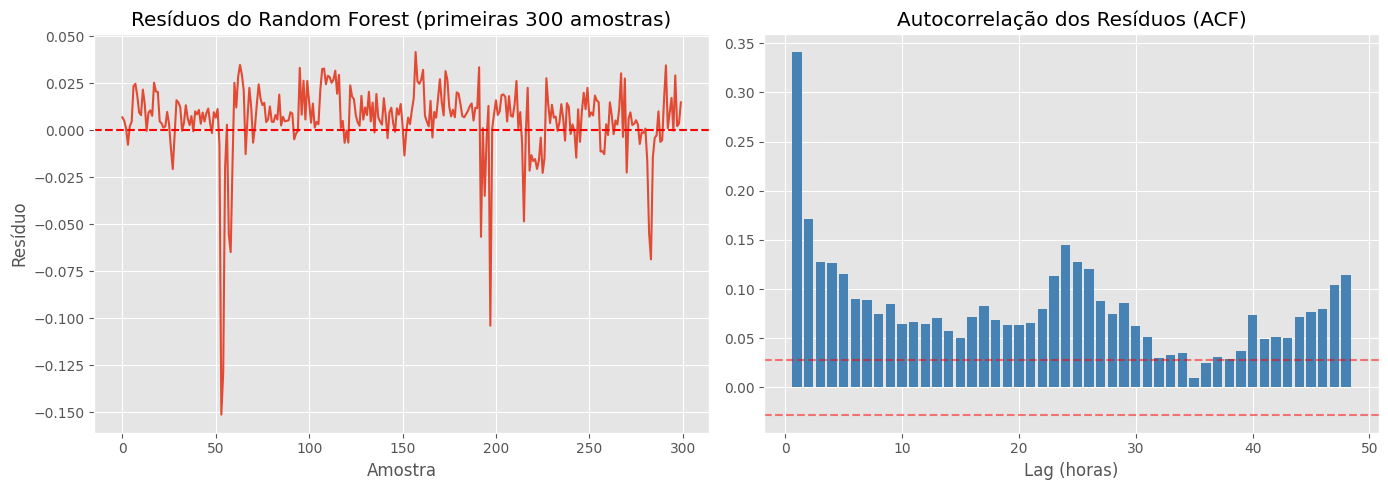

In [29]:
# autocorrelação dos resíduos do melhor modelo (Random Forest)
residuos_rf = y_test.values - pred_rf_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(residuos_rf[:300])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Resíduos do Random Forest (primeiras 300 amostras)')
axes[0].set_xlabel('Amostra')
axes[0].set_ylabel('Resíduo')

# calculando ACF na mão
n_lags = 48
n = len(residuos_rf)
acf_vals = [np.corrcoef(residuos_rf[:-k], residuos_rf[k:])[0, 1]
            for k in range(1, n_lags + 1)]
axes[1].bar(range(1, n_lags + 1), acf_vals, color='steelblue')
axes[1].axhline(y=1.96 / np.sqrt(n), color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-1.96 / np.sqrt(n), color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Autocorrelação dos Resíduos (ACF)')
axes[1].set_xlabel('Lag (horas)')

plt.tight_layout()
plt.show()

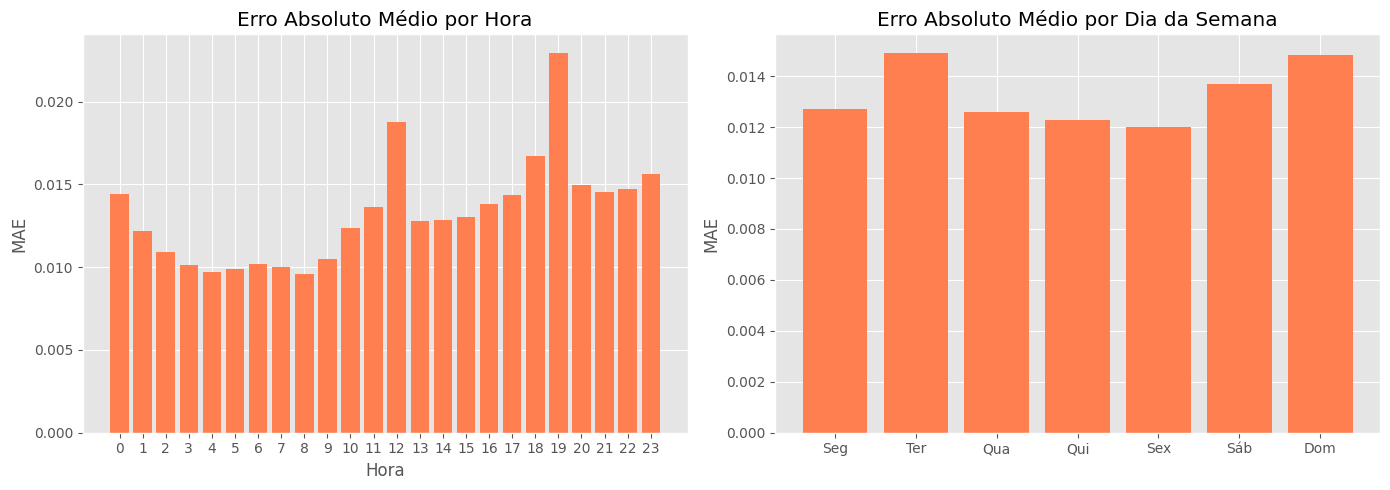

In [30]:
# onde o modelo erra mais?
df_erro = pd.DataFrame({
    'real': y_test.values,
    'pred': pred_rf_test,
    'erro_abs': np.abs(y_test.values - pred_rf_test),
    'hour': X_test['hour'].values,
    'day_of_week': X_test['day_of_week'].values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

erro_hora = df_erro.groupby('hour')['erro_abs'].mean()
axes[0].bar(erro_hora.index, erro_hora.values, color='coral')
axes[0].set_title('Erro Absoluto Médio por Hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(range(0, 24))

dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
erro_dia = df_erro.groupby('day_of_week')['erro_abs'].mean()
axes[1].bar(range(7), erro_dia.values, color='coral', tick_label=dias)
axes[1].set_title('Erro Absoluto Médio por Dia da Semana')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

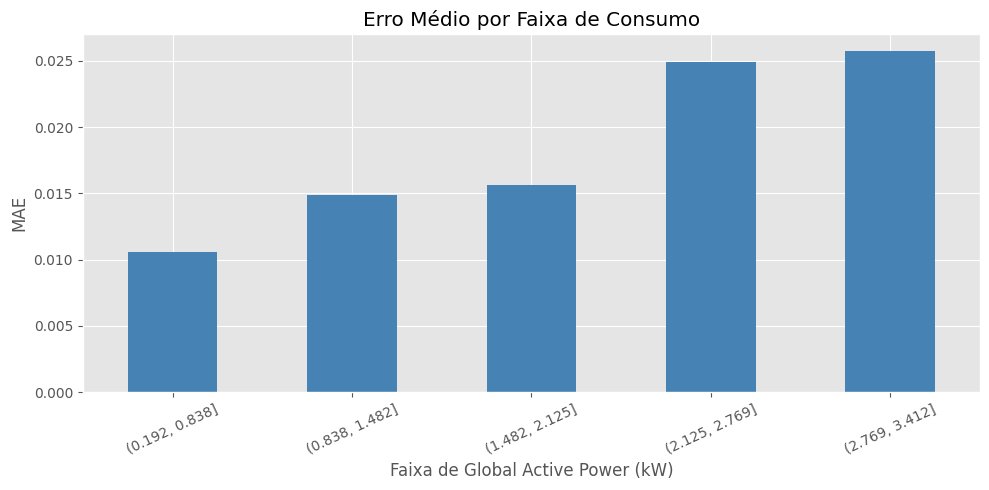

In [31]:
# distribuição dos erros por faixa de consumo
df_erro['faixa'] = pd.cut(df_erro['real'], bins=5)

erro_faixa = df_erro.groupby('faixa')['erro_abs'].mean()

plt.figure(figsize=(10, 5))
erro_faixa.plot(kind='bar', color='steelblue')
plt.title('Erro Médio por Faixa de Consumo')
plt.xlabel('Faixa de Global Active Power (kW)')
plt.ylabel('MAE')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Conclusão

O **Random Forest** foi o melhor modelo entre os três testados, com menor erro e maior R². Alguns pontos importantes que observamos:

- O consumo de energia tem dois picos durante o dia: um de manhã (~7-9h) e outro à noite (~19-21h), o que era esperado
- O **lag_1h** (consumo da hora anterior) é disparado a feature mais importante — o que a pessoa consumiu na última hora é o melhor preditor do que vai consumir agora
- A **hora do dia** também pesa bastante no modelo
- Fim de semana tem padrão de consumo diferente dos dias úteis
- O modelo erra mais nos horários de pico, justamente quando o consumo é mais variável entre os dias
- Nos resíduos, ainda existe autocorrelação, o que sugere que modelos de séries temporais mais especializados (ARIMA, LSTM) poderiam capturar melhor essa estrutura
- A regressão polinomial não trouxe grande melhoria em relação à linear simples, provavelmente porque a não-linearidade do problema é melhor capturada por árvores de decisão do que por termos polinomiais

# Modelo Final Salvo

In [33]:
import joblib
import os

# Salvar modelo com compressão máxima
joblib.dump(rf, 'modelo_final.joblib', compress=('xz', 9))

# Salvar scaler com compressão
joblib.dump(scaler, 'scaler.joblib', compress=('xz', 9))

# Mostrar tamanho dos arquivos
modelo_mb = os.path.getsize('modelo_final.joblib') / (1024 * 1024)
scaler_mb = os.path.getsize('scaler.joblib') / (1024 * 1024)

print(f"✅ Modelo salvo: {modelo_mb:.2f} MB")
print(f"✅ Scaler salvo: {scaler_mb:.2f} MB")

# Download dos arquivos
from google.colab import files

files.download('modelo_final.joblib')
files.download('scaler.joblib')

✅ Modelo salvo: 13.12 MB
✅ Scaler salvo: 0.00 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>